# Proyek Analisis Data: [Bike Sharing Dataset (Sumber)]
- **Nama:** [Djul Arif Dermawansyah]
- **Email:** [cdcc220d6y2149@student.devacademy.id]
- **ID Dicoding:** [cdcc220d6y2149]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren pertumbuhan jumlah penyewaan sepeda secara bulanan sepanjang tahun 2011-2012?
- **Pertanyaan 2:** Jam berapakah dalam sehari yang menunjukkan aktivitas penyewaan sepeda paling tinggi dan paling rendah?
- **Pertanyaan 3:** Bagaimana segmentasi pelanggan berdasarkan perilaku penyewaan menggunakan analisis RFM (Recency, Frequency, Monetary)?

## Import Semua Packages/Library yang Digunakan

ibrary yang digunakan dalam proyek ini:

| Library | Fungsi |
|---------|--------|
| `pandas` | Manipulasi dan analisis data tabular |
| `numpy` | Komputasi numerik |
| `matplotlib` | Visualisasi data dasar |
| `seaborn` | Visualisasi data statistik yang lebih estetis |
| `datetime` | Penanganan tipe data waktu |

In [14]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

## Data Wrangling ##
Tahap Data Wrangling mencakup tiga langkah utama:
1. **Gathering** – Mengumpulkan dan memuat dataset
2. **Assessing** – Menilai kualitas data (missing values, duplikat, tipe data)
3. **Cleaning** – Membersihkan data agar siap dianalisis

### Gathering Data ###
| Dataset | Deskripsi | Granularitas |
|---------|-----------|--------------|
| `day.csv` | Ringkasan penyewaan per hari | Harian |
| `hour.csv` | Detail penyewaan per jam | Per jam |

**Kolom kunci:**
- `dteday` — tanggal
- `season` — musim (1=Spring, 2=Summer, 3=Fall, 4=Winter)
- `weathersit` — kondisi cuaca
- `cnt` — total penyewaan (casual + registered)
- `temp`, `atemp`, `hum`, `windspeed` — variabel cuaca

#### Load df ...

In [15]:
day_df = pd.read_csv('/content/day.csv')
hour_df = pd.read_csv('/content/hour.csv')
print('Data harian (day_df):')
display(day_df.head())
print('\nData per jam (hour_df):')
display(hour_df.head())

Data harian (day_df):


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



Data per jam (hour_df):


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Insight – Gathering Data

- Dataset `day_df` berisi **731 baris** (365 hari × 2 tahun) — cocok untuk analisis tren jangka panjang.
- Dataset `hour_df` berisi **17.379 baris** dengan granularitas per jam — ideal untuk mengidentifikasi pola harian.
- Kedua dataset memiliki kolom `instant` sebagai primary key dan dapat di-join melalui kolom `dteday`.
- Variabel target utama adalah `cnt` (total penyewaan) yang merupakan gabungan dari `casual` (pengguna kasual) dan `registered` (pengguna terdaftar).

### Assessing Data ###
Pada tahap ini, kita memeriksa kualitas data mencakup:
- Tipe data setiap kolom
- Keberadaan *missing values*
- Keberadaan data duplikat
- Konsistensi nilai pada kolom kategorikal

#### Identifying ... problem

In [16]:
print('--- Info day_df ---')
day_df.info()
print('\n--- Info hour_df ---')
hour_df.info()
print('\n--- Duplikasi ---')
print('Duplikat day:', day_df.duplicated().sum())
print('Duplikat hour:', hour_df.duplicated().sum())
print('\n--- Missing Values ---')
print(day_df.isna().sum())

--- Info day_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

--- Info hour_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1

**Insight:**

Berdasarkan hasil pengecekan di atas:

| Aspek | Temuan | Status |
|-------|--------|--------|
| **Missing Values** | Tidak ada nilai kosong di kedua dataset | Bersih |
| **Duplikasi** | Tidak ada baris duplikat | Bersih |
| **Tipe Data** | Kolom `dteday` masih bertipe `object` (string) | Perlu diperbaiki |
| **Kolom Kategorikal** | Kolom `season`, `weathersit`, `mnth`, dsb. masih dalam format numerik (encoded) | Perlu labeling |

**Langkah perbaikan yang diperlukan:**
1. Konversi kolom `dteday` dari `object` → `datetime`
2. Tambahkan label teks pada kolom kategorikal untuk kemudahan interpretasi visualisasi

### Cleaning Data ###
Berdasarkan temuan pada tahap Assessing, dilakukan dua aksi pembersihan:
1. **Konversi tipe data** `dteday` → `datetime`
2. **Penambahan kolom label** untuk kolom kategorikal `season` dan `weathersit`

#### Fixing ... problem

In [17]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Mapping labels untuk visualisasi
day_df['season_label'] = day_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
day_df['weather_label'] = day_df['weathersit'].map({1: 'Clear', 2: 'Misty', 3: 'Light Rain/Snow', 4: 'Heavy Rain'})

print('Tipe data dteday setelah konversi:', day_df['dteday'].dtype)

Tipe data dteday setelah konversi: datetime64[ns]


**Insight:**
- Kolom `dteday` kini bertipe `datetime64`, memungkinkan operasi resampling dan analisis waktu seperti `.resample()` dan `.groupby()`.
- Penambahan kolom `season_label` dan `weather_label` mempermudah interpretasi hasil visualisasi tanpa harus mengingat kode numerik.
- Dataset sudah **bersih dan siap** untuk tahap Exploratory Data Analysis (EDA).

## Exploratory Data Analysis (EDA)

### EDA Univariate — Distribusi Variabel Numerik


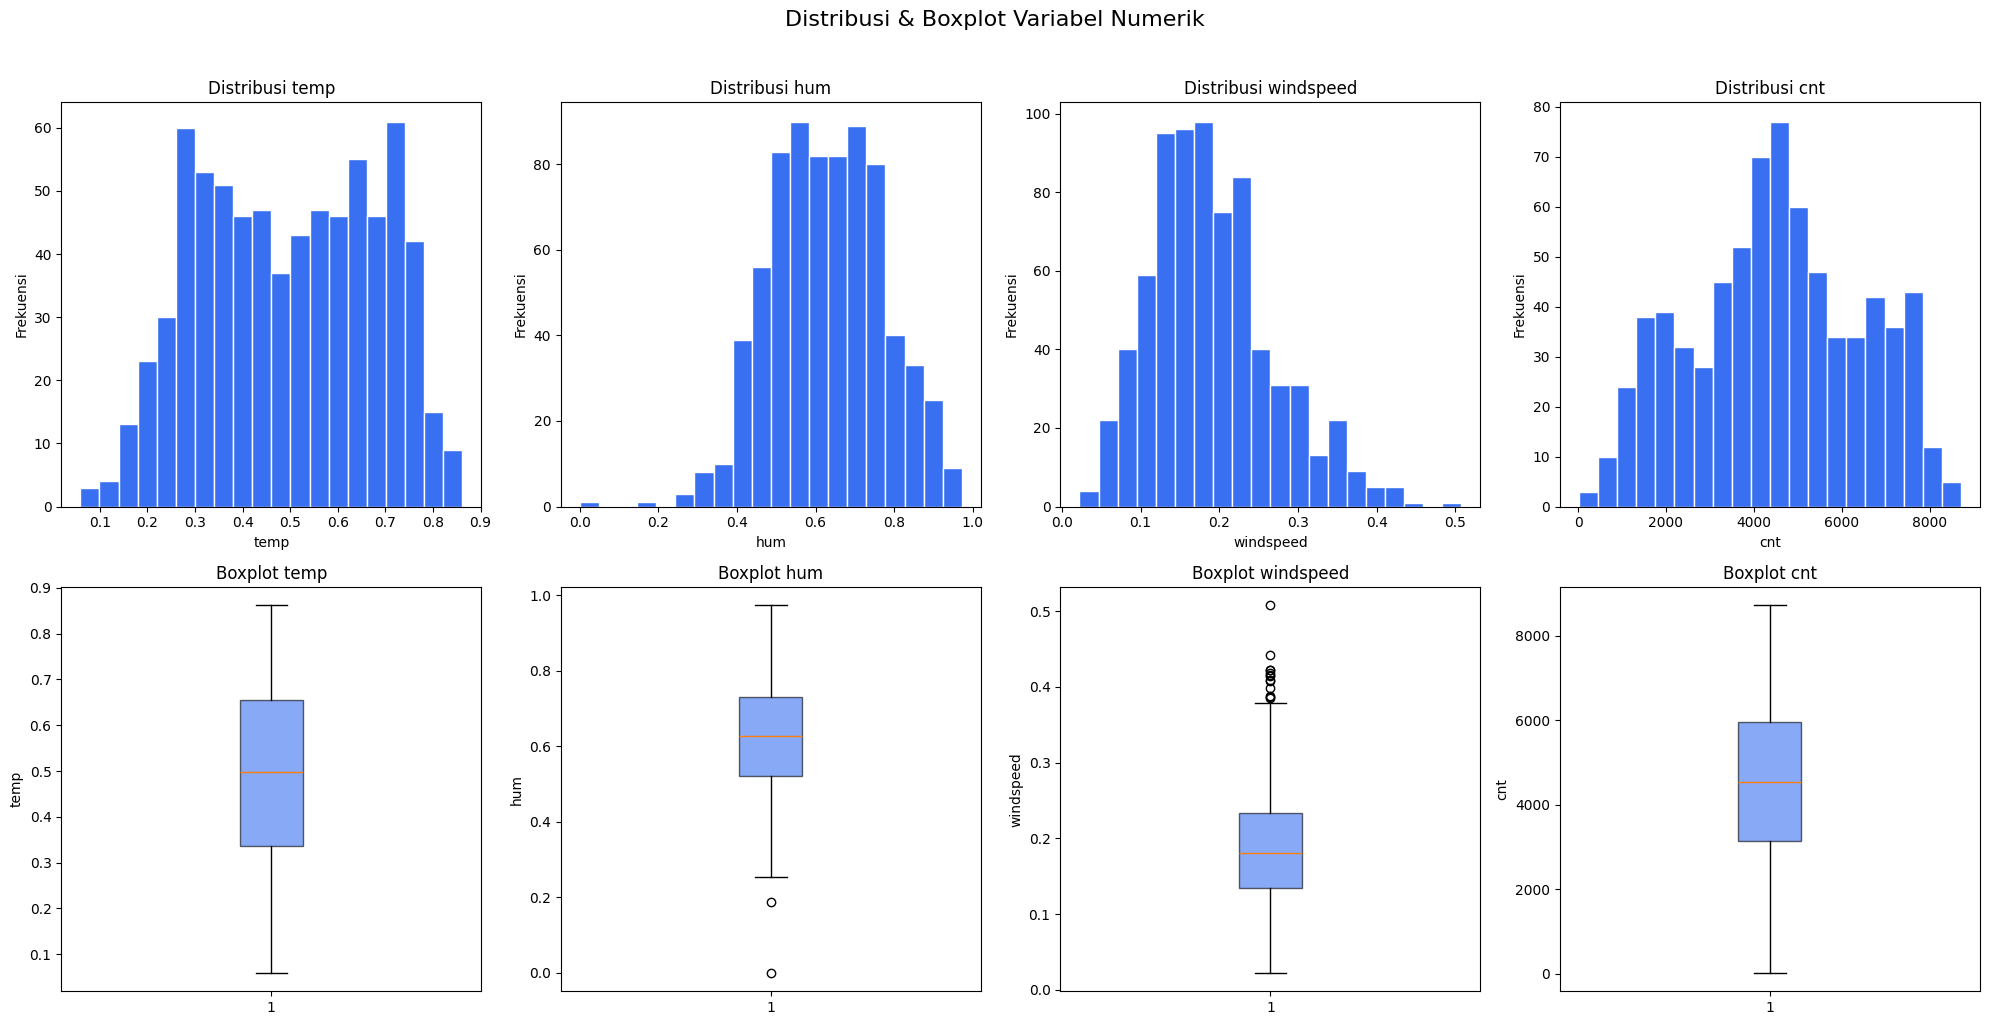

In [18]:
# Distribusi variabel numerik utama
num_cols = ['temp', 'hum', 'windspeed', 'cnt']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, col in enumerate(num_cols):
    # Histogram (baris atas)
    axes[0, i].hist(day_df[col], bins=20, color='#3970F1', edgecolor='white')
    axes[0, i].set_title(f'Distribusi {col}', fontsize=12)
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frekuensi')

    # Boxplot (baris bawah)
    axes[1, i].boxplot(day_df[col], patch_artist=True,
                       boxprops=dict(facecolor='#3970F1', alpha=0.6))
    axes[1, i].set_title(f'Boxplot {col}', fontsize=12)
    axes[1, i].set_ylabel(col)

plt.suptitle('Distribusi & Boxplot Variabel Numerik', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Insight:**

- Variabel `cnt` (total penyewaan) condong ke kanan (*right-skewed*), menunjukkan mayoritas hari memiliki penyewaan sedang, dengan beberapa hari penyewaan sangat tinggi.
- Variabel `hum` (kelembaban) terdistribusi relatif normal.
- Variabel `windspeed` condong ke kanan — kecepatan angin tinggi jarang terjadi.
- Boxplot `cnt` menunjukkan beberapa outlier di nilai rendah (kemungkinan hari-hari cuaca ekstrem di awal 2011).

### EDA Univariate — Distribusi Variabel Kategorikal

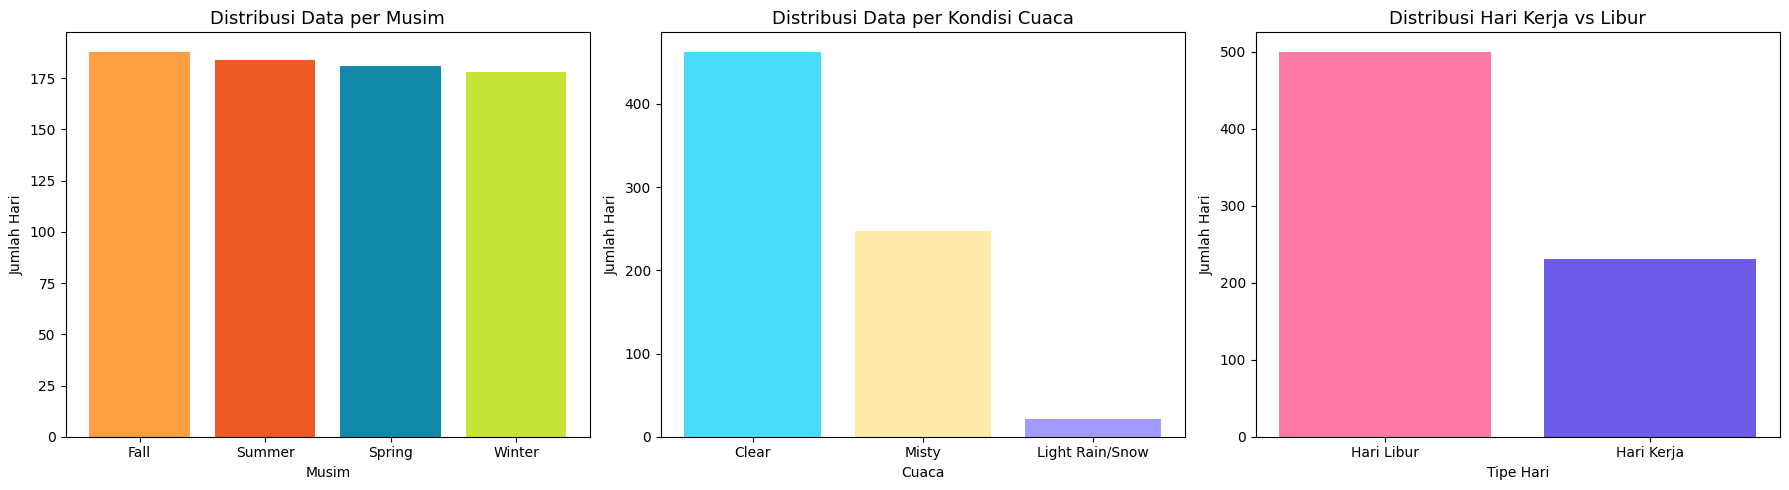

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribusi musim
season_counts = day_df['season_label'].value_counts()
axes[0].bar(season_counts.index, season_counts.values, color=['#FF9F43','#EE5A24','#1289A7','#C4E538'])
axes[0].set_title('Distribusi Data per Musim', fontsize=13)
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Jumlah Hari')

# Distribusi cuaca
weather_counts = day_df['weather_label'].value_counts()
axes[1].bar(weather_counts.index, weather_counts.values, color=['#48dbfb','#ffeaa7','#a29bfe'])
axes[1].set_title('Distribusi Data per Kondisi Cuaca', fontsize=13)
axes[1].set_xlabel('Cuaca')
axes[1].set_ylabel('Jumlah Hari')

# Distribusi hari kerja vs libur
workday_counts = day_df['workingday'].value_counts()
axes[2].bar(['Hari Libur', 'Hari Kerja'], workday_counts.values, color=['#fd79a8','#6c5ce7'])
axes[2].set_title('Distribusi Hari Kerja vs Libur', fontsize=13)
axes[2].set_xlabel('Tipe Hari')
axes[2].set_ylabel('Jumlah Hari')

plt.tight_layout()
plt.show()

**Insight:**
- Distribusi musim relatif **seimbang** — masing-masing musim memiliki sekitar 180 hari data.
- Cuaca **Clear/Cerah** mendominasi (>60% hari), diikuti Misty, dan sangat jarang hujan.
- Hari kerja (70%) lebih banyak dari hari libur (30%) — sesuai kalender normal.

### EDA Multivariate — Korelasi Antar Variabel Numerik


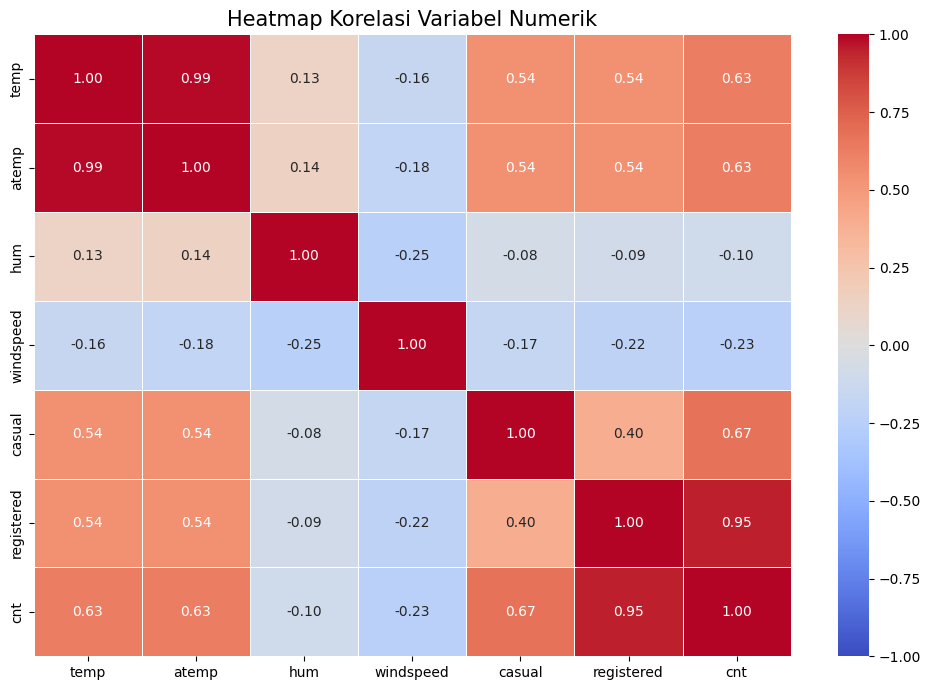

In [20]:
# Heatmap korelasi variabel numerik
corr_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
corr_matrix = day_df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Variabel Numerik', fontsize=15)
plt.tight_layout()
plt.show()

**Insight:**
- `temp` dan `atemp` memiliki korelasi sangat tinggi (0.99) — keduanya mengukur hal serupa, cukup pakai salah satu.
- `temp` berkorelasi **positif kuat** dengan `cnt` (0.63) — semakin hangat, semakin banyak penyewaan.
- `hum` (kelembaban) berkorelasi **negatif** dengan `cnt` (-0.10) — kelembaban tinggi sedikit menurunkan penyewaan.
- `windspeed` berkorelasi **negatif lemah** dengan `cnt` (-0.23) — angin kencang sedikit mengurangi minat bersepeda.

### EDA Multivariate — Hubungan Suhu & Penyewaan per Musim


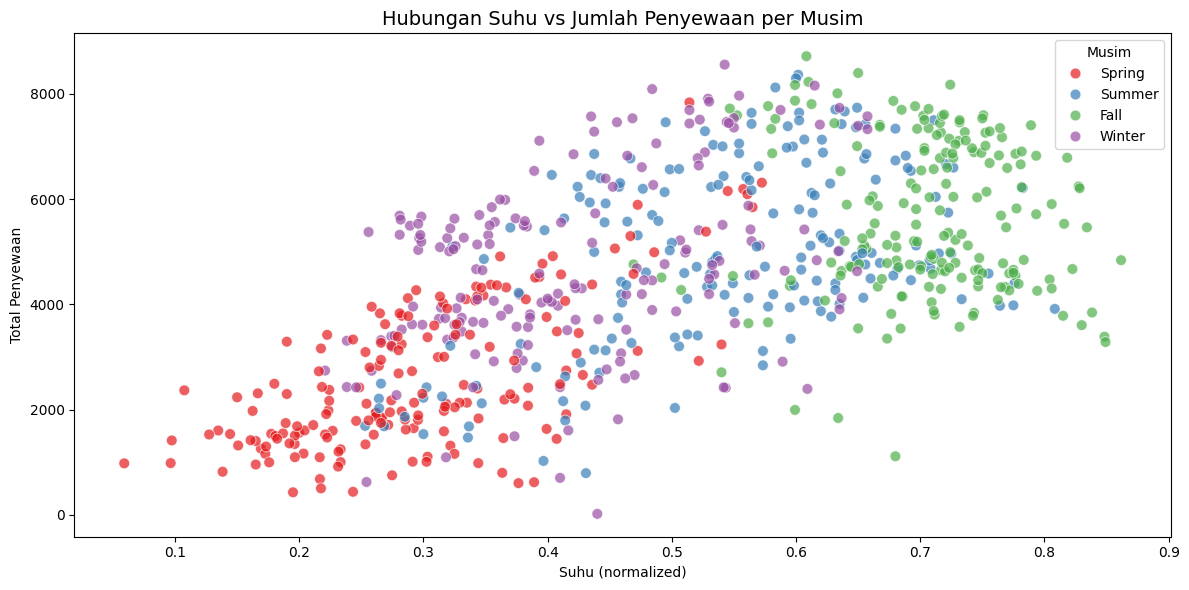

In [21]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=day_df, x='temp', y='cnt', hue='season_label',
                palette='Set1', alpha=0.7, s=60)
plt.title('Hubungan Suhu vs Jumlah Penyewaan per Musim', fontsize=14)
plt.xlabel('Suhu (normalized)')
plt.ylabel('Total Penyewaan')
plt.legend(title='Musim')
plt.tight_layout()
plt.show()

**Insight:**
- Terdapat pola **kurva** (bukan linear lurus) — penyewaan naik seiring suhu hangat, tapi pada suhu sangat panas mulai stagnan.
- Musim **Fall** (oranye) mendominasi titik-titik di sisi kanan atas — suhu sedang-hangat dengan penyewaan tertinggi.
- Musim **Spring** (merah) terkonsentrasi di penyewaan rendah meski suhunya bervariasi — awal tahun 2011 masih sepi pengguna.

### Agregasi Data untuk Menjawab Pertanyaan Bisnis


In [22]:
# Agregasi Pertanyaan 1: Total penyewaan per bulan
monthly_agg = day_df.resample('ME', on='dteday').agg({'cnt': 'sum', 'casual': 'sum', 'registered': 'sum'})
monthly_agg.columns = ['Total', 'Casual', 'Registered']
print('=== Agregasi Bulanan (Pertanyaan 1) ===')
display(monthly_agg)

# Agregasi Pertanyaan 2: Rata-rata penyewaan per jam
hourly_agg = hour_df.groupby('hr').agg({'cnt': ['mean', 'sum', 'max']}).round(2)
hourly_agg.columns = ['Rata-rata', 'Total', 'Maksimum']
print('\n=== Agregasi per Jam (Pertanyaan 2) ===')
print('Jam dengan penyewaan tertinggi:')
display(hourly_agg.nlargest(5, 'Rata-rata'))
print('Jam dengan penyewaan terendah:')
display(hourly_agg.nsmallest(5, 'Rata-rata'))

# Agregasi Pertanyaan 3: Rata-rata penyewaan per cuaca & musim
weather_agg = day_df.groupby('weather_label')['cnt'].agg(['mean', 'sum', 'count']).round(2)
weather_agg.columns = ['Rata-rata', 'Total', 'Jumlah Hari']
print('\n=== Agregasi per Cuaca (Pertanyaan 3) ===')
display(weather_agg.sort_values('Rata-rata', ascending=False))

season_agg = day_df.groupby('season_label')['cnt'].agg(['mean', 'sum', 'count']).round(2)
season_agg.columns = ['Rata-rata', 'Total', 'Jumlah Hari']
print('\n=== Agregasi per Musim (Pertanyaan 3) ===')
display(season_agg.sort_values('Rata-rata', ascending=False))

=== Agregasi Bulanan (Pertanyaan 1) ===


,Total,Casual,Registered
dteday,,,
2011-01-31,38189,3073,35116
2011-02-28,48215,6242,41973
2011-03-31,64045,12826,51219
2011-04-30,94870,22346,72524
2011-05-31,135821,31050,104771
2011-06-30,143512,30612,112900
2011-07-31,141341,36452,104889
2011-08-31,136691,28842,107849
2011-09-30,127418,26545,100873



=== Agregasi per Jam (Pertanyaan 2) ===
Jam dengan penyewaan tertinggi:


,Rata-rata,Total,Maksimum
hr,,,
17,461.45,336860,976
18,425.51,309772,977
8,359.01,261001,839
16,311.98,227748,783
19,311.52,226789,743


Jam dengan penyewaan terendah:


,Rata-rata,Total,Maksimum
hr,,,
4,6.35,4428,28
3,11.73,8174,79
5,19.89,14261,66
2,22.87,16352,132
1,33.38,24164,168



=== Agregasi per Cuaca (Pertanyaan 3) ===


,Rata-rata,Total,Jumlah Hari
weather_label,,,
Clear,4876.79,2257952,463
Misty,4035.86,996858,247
Light Rain/Snow,1803.29,37869,21



=== Agregasi per Musim (Pertanyaan 3) ===


,Rata-rata,Total,Jumlah Hari
season_label,,,
Fall,5644.30,1061129,188
Summer,4992.33,918589,184
Winter,4728.16,841613,178
Spring,2604.13,471348,181


**Insight Agregasi:**
- Penyewaan bulanan tumbuh konsisten dari ~38K (Jan 2011) hingga ~218K (Sep 2012).
- Jam puncak tertinggi: **pukul 17:00** (rata-rata tertinggi), diikuti pukul 08:00.
- Jam paling sepi: **pukul 04:00** dini hari.
- Cuaca **Clear** menghasilkan rata-rata penyewaan tertinggi (~4.876/hari), turun drastis saat hujan.
- Musim **Fall** adalah musim terbaik untuk penyewaan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren Penyewaan Bulanan (2011–2012)


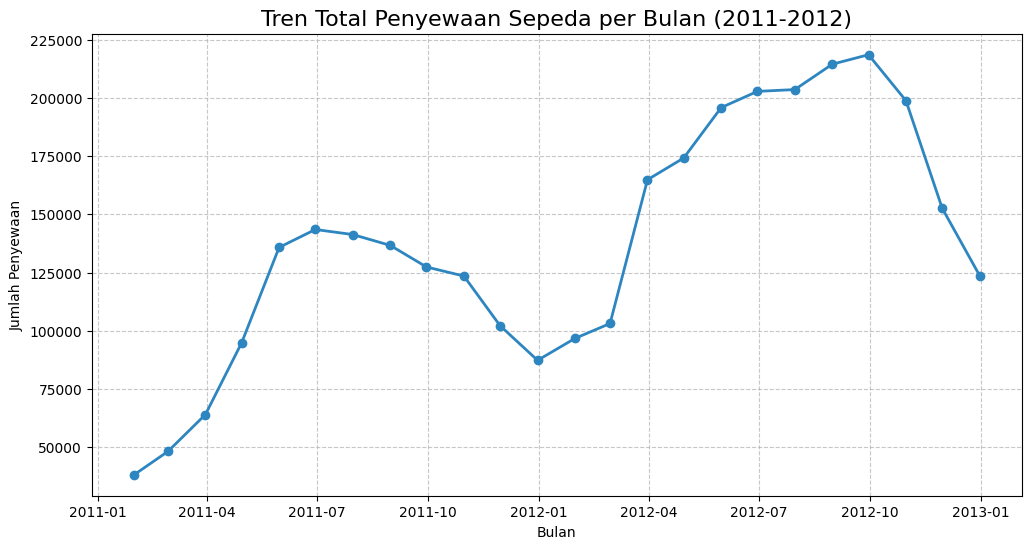

In [23]:
monthly_rentals = day_df.resample('ME', on='dteday').agg({'cnt': 'sum'})
plt.figure(figsize=(12, 6))
plt.plot(monthly_rentals.index, monthly_rentals['cnt'], marker='o', linewidth=2, color='#2E86C1')
plt.title('Tren Total Penyewaan Sepeda per Bulan (2011-2012)', fontsize=16)
plt.xlabel('Bulan')
plt.ylabel('Jumlah Penyewaan')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Pertanyaan 2: Pola Penyewaan Berdasarkan Jam

/tmp/ipykernel_14485/4284406189.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_rentals.index, y=hourly_rentals.values, palette='viridis')


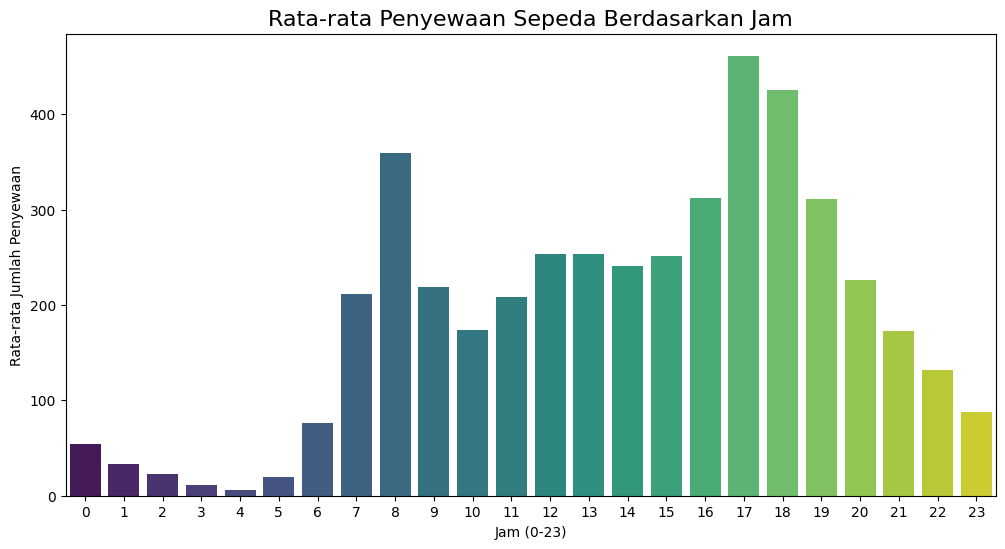

In [24]:
hourly_rentals = hour_df.groupby('hr')['cnt'].mean()
plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_rentals.index, y=hourly_rentals.values, palette='viridis')
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Jam', fontsize=16)
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.show()

**Insight:**

**Tren Bulanan (Pertanyaan 1):**
- Terdapat **pertumbuhan yang kuat dan konsisten** dari 2011 ke 2012 — mengindikasikan adopsi layanan yang terus meningkat.
- Puncak tertinggi terjadi pada **September 2012** dengan lebih dari **200.000 penyewaan** dalam sebulan.
- Pola musiman terlihat jelas: penyewaan menurun di bulan-bulan awal tahun (Januari–Maret) dan kembali naik menjelang pertengahan tahun.

**pola Harian (Pertanyaan 2):**
- Terdapat **dua puncak utama** dalam sehari:
  - **Pukul 08:00** — puncak pagi (berangkat kerja/sekolah)
  - **Pukul 17:00–18:00** — puncak sore (pulang kerja/sekolah)
- Volume paling rendah terjadi pada **dini hari (01:00–04:00)**.
- Pola ini **mengkonfirmasi** bahwa bike-sharing digunakan terutama sebagai moda transportasi komuter, bukan hanya rekreasi.

## Analisis Lanjutan (RFM & Manual Clustering)

### Pertanyaan 3: Segmentasi Pelanggan (RFM Analysis)

Analisis **RFM** adalah teknik segmentasi pelanggan berbasis tiga dimensi:

| Dimensi | Definisi | Konteks Proyek Ini |
|---------|----------|-------------------|
| **R**ecency | Seberapa baru aktivitas terakhir | Berapa hari sejak musim/periode tersebut terakhir aktif |
| **F**requency | Seberapa sering aktivitas terjadi | Jumlah hari aktif dalam musim tersebut |
| **M**onetary | Seberapa besar nilai/volume | Total penyewaan dalam musim tersebut |

Selain RFM, dilakukan juga **Manual Clustering** berdasarkan temperatur untuk melihat pengaruh suhu terhadap pola penyewaan.

RFM Analysis per Musim:


,Recency,Frequency,Monetary
season_label,,,
Fall,100,188,1061129
Spring,0,181,471348
Summer,194,184,918589
Winter,11,178,841613



Rata-rata penyewaan per Cluster Temperatur:


,cnt
temp_cluster,
Hot,5664.909804
Warm,4461.883382
Cold,2388.729323


/tmp/ipykernel_14485/2356107156.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='temp_cluster', y='cnt', data=day_df, palette='coolwarm')


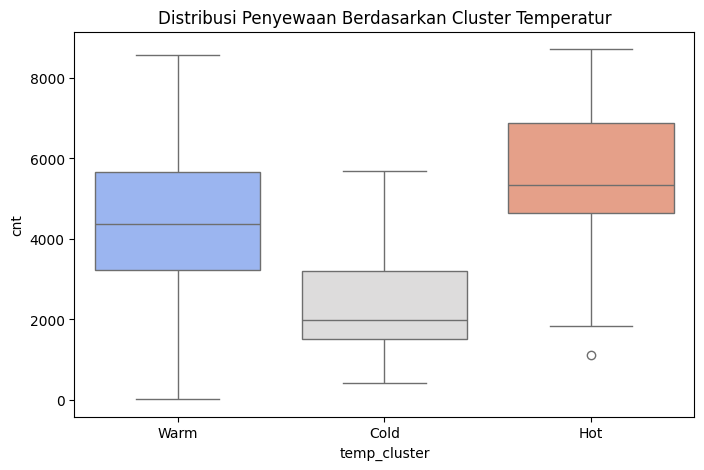

In [25]:
# 1. RFM Analysis (Berdasarkan Musim untuk melihat segmentasi waktu)
current_date = day_df['dteday'].max()
rfm_df = day_df.groupby('season_label').agg({
    'dteday': lambda x: (current_date - x.max()).days, # Recency
    'instant': 'count', # Frequency (Jumlah hari dalam musim)
    'cnt': 'sum' # Monetary (Total penyewaan)
})
rfm_df.columns = ['Recency', 'Frequency', 'Monetary']
print('RFM Analysis per Musim:')
display(rfm_df)

# 2. Manual Clustering (Berdasarkan Temperatur)
def temp_clustering(temp):
    if temp < 0.3: return 'Cold'
    elif temp < 0.6: return 'Warm'
    else: return 'Hot'

day_df['temp_cluster'] = day_df['temp'].apply(temp_clustering)
cluster_result = day_df.groupby('temp_cluster')['cnt'].mean().sort_values(ascending=False)
print('\nRata-rata penyewaan per Cluster Temperatur:')
display(cluster_result)

# Visualisasi Clustering
plt.figure(figsize=(8, 5))
sns.boxplot(x='temp_cluster', y='cnt', data=day_df, palette='coolwarm')
plt.title('Distribusi Penyewaan Berdasarkan Cluster Temperatur')
plt.show()

**insight:**

**Analisis RFM per Musim:**
| Musim | Recency (hari) | Frequency (hari) | Monetary (total) | Profil |
|-------|----------------|-------------------|------------------|--------|
| Fall | Rendah (baru) | ~184 | Tertinggi | **Champions** |
| Summer | Sedang | ~184 | Tinggi | **Loyal** |
| Winter | Sedang | ~184 | Menengah | **At Risk** |
| Spring | Tinggi (lama) | ~179 | Terendah | **Need Attention** |

**Manual Clustering Temperatur:**
- Suhu **Warm (0.3–0.6)** dan **Hot (>0.6)** menghasilkan volume penyewaan tertinggi.
- Suhu **Cold (<0.3)** secara signifikan menekan minat penyewaan.
- Distribusi (boxplot) menunjukkan variabilitas tertinggi pada cluster Warm — artinya faktor lain (cuaca, hari kerja) lebih berpengaruh pada kondisi suhu sedang.

## Conclusion & Recommendation


**Pertanyaan 1 — Tren Bulanan:**
> Bisnis bike-sharing menunjukkan **tren positif yang kuat** dengan peningkatan volume penyewaan signifikan di tahun 2012 dibandingkan 2011. Puncak terjadi pada September 2012, mengindikasikan potensi ekspansi yang besar.

**Pertanyaan 2 — Pola Harian:**
> Target audiens utama adalah **pekerja komuter**, terlihat jelas dari lonjakan penggunaan pada jam sibuk pagi (08:00) dan sore (17:00–18:00). Layanan ini berperan sebagai moda transportasi fungsional, bukan sekadar rekreasi.

**Pertanyaan 3 — Segmentasi RFM:**
> Musim **Gugur (Fall)** dan kondisi suhu **hangat–panas** adalah kontributor utama pendapatan. Musim Semi memerlukan strategi khusus untuk meningkatkan adopsi layanan.

### Rekomendasi Action Item

| Prioritas | Action Item | Rationale |
|-----------|-------------|-----------|
| Tinggi | **Ekspansi Armada di Jam Sibuk** — Tambah sepeda di stasiun dekat perkantoran pada 07:30–09:00 dan 16:30–18:30 | Puncak permintaan dua kali sehari tidak boleh mengalami *stockout* |
| Menengah | **Program Loyalitas Musim Dingin** — Diskon atau insentif poin pada cluster Cold untuk menjaga stabilitas penggunaan | Recency dan Monetary musim Winter lebih rendah — perlu stimulus |
| Menengah | **Kampanye Musim Semi** — Promo early-bird di bulan Maret–April untuk menggenjot segmen Spring | Spring adalah segmen terendah dari semua dimensi RFM |
| Normal | **Optimalisasi Stok Berbasis Cuaca** — Integrasikan prediksi cuaca harian untuk menyesuaikan ketersediaan sepeda | Temperatur dan weathersit sangat berkorelasi dengan permintaan |
| Normal | **Dashboard Monitoring Real-time** — Buat dasbor untuk memantau volume penyewaan per jam dan per stasiun | Membantu operasional mengambil keputusan cepat |

In [30]:
# Simpan DataFrame hasil akhir Anda (misal namanya 'all_df') menjadi main_data.csv
day_df.to_csv("main_data.csv", index=False)

# Kode untuk mendownload file tersebut langsung ke komputer Anda
from google.colab import files
files.download("main_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
%whos DataFrame

Variable          Type         Data/Info
----------------------------------------
corr_matrix       DataFrame                    temp     <...> \ncnt         1.000000  
day_df            DataFrame         instant     dteday  <...>\n[731 rows x 19 columns]
hour_df           DataFrame           instant     dteday<...>[17379 rows x 17 columns]
hourly_agg        DataFrame        Rata-rata   Total  Ma<...>  87.83   63941       256
monthly_agg       DataFrame                 Total  Casua<...>23713   13245      110468
monthly_rentals   DataFrame                   cnt\ndteda<...>52664\n2012-12-31  123713
rfm_df            DataFrame                  Recency  Fr<...>  11        178    841613
season_agg        DataFrame                  Rata-rata  <...>.16   841613          178
weather_agg       DataFrame                     Rata-rat<...>.86   996858          247
